In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,  
    ReduceLROnPlateau)
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
GPU Available: []


In [2]:
import os
for split in ["train", "valid"]:
    split_path = os.path.join(
        r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2",
        split
    )
    print(f"\n========== {split.upper()} ==========")
    total = 0
    for plant in sorted(os.listdir(split_path)):
        plant_path = os.path.join(split_path, plant)
        if os.path.isdir(plant_path):
            plant_total = 0
            for disease in os.listdir(plant_path):
                disease_path = os.path.join(plant_path, disease)
                if os.path.isdir(disease_path):
                    count = len([
                        f for f in os.listdir(disease_path)
                        if f.lower().endswith((".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"))
                    ])
                    print(f"{plant} -> {disease}: {count}")
                    plant_total += count
            print(f"{plant} TOTAL: {plant_total}")
            total += plant_total
    print(f"\nTOTAL {split.upper()} IMAGES: {total}")


========== TRAIN ==========
Apple -> Apple Scab: 2016
Apple -> Black Rot: 1987
Apple -> Cedar Apple Rust: 1760
Apple -> Healthy: 2008
Apple TOTAL: 7771
Cherry -> Healthy: 1826
Cherry -> Powdery Mildew: 1683
Cherry TOTAL: 3509
Corn -> Common Rust: 1907
Corn -> Gray Leaf Spot: 1642
Corn -> Healthy: 1859
Corn -> Northern Leaf Blight: 1908
Corn TOTAL: 7316
Grape -> Black Rot: 1888
Grape -> Esca: 1920
Grape -> Healthy: 1692
Grape -> Leaf Blight: 1722
Grape TOTAL: 7222
Peach -> Bacterial Spot: 1838
Peach -> Healthy: 1728
Peach TOTAL: 3566
Pepper -> Bacterial Spot: 1913
Pepper -> Healthy: 1988
Pepper TOTAL: 3901
Potato -> Early Blight: 1939
Potato -> Healthy: 1824
Potato -> Late Blight: 1939
Potato TOTAL: 5702
Strawberry -> Healthy: 1824
Strawberry -> Leaf Scorch: 1774
Strawberry TOTAL: 3598
Tomato -> Bacterial Spot: 1702
Tomato -> Early Blight: 1920
Tomato -> Healthy: 1926
Tomato -> Late Blight: 1851
Tomato TOTAL: 7399

TOTAL TRAIN IMAGES: 49984

========== VALID ==========
Apple -> Apple S

In [3]:
TRAIN_DIR = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\train"
VALID_DIR = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\valid"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Train Directory:", TRAIN_DIR)
print("Validation Directory:", VALID_DIR)

Train Directory: D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\train
Validation Directory: D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\valid


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(
    rescale=1./255
)
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)
valid_data = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
print("Training Images :", train_data.samples)
print("Validation Images :", valid_data.samples)
print("Number of Classes :", train_data.num_classes)
print("Classes :")
print(train_data.class_indices)

Found 49984 images belonging to 9 classes.
Found 12494 images belonging to 9 classes.
Training Images : 49984
Validation Images : 12494
Number of Classes : 9
Classes :
{'Apple': 0, 'Cherry': 1, 'Corn': 2, 'Grape': 3, 'Peach': 4, 'Pepper': 5, 'Potato': 6, 'Strawberry': 7, 'Tomato': 8}


In [5]:
print("Train classes :", train_data.num_classes)
print("Valid classes :", valid_data.num_classes)

print("\nClass mapping:")
for name, index in train_data.class_indices.items():
    print(index, "->", name)

Train classes : 9
Valid classes : 9

Class mapping:
0 -> Apple
1 -> Cherry
2 -> Corn
3 -> Grape
4 -> Peach
5 -> Pepper
6 -> Potato
7 -> Strawberry
8 -> Tomato


In [6]:
import os
TRAIN_DIR = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\train"
VALID_DIR = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\valid"
train_classes = []
valid_classes = []
for crop in sorted(os.listdir(TRAIN_DIR)):
    crop_path = os.path.join(TRAIN_DIR, crop)

    if os.path.isdir(crop_path):
        for disease in sorted(os.listdir(crop_path)):
            disease_path = os.path.join(crop_path, disease)

            if os.path.isdir(disease_path):
                train_classes.append(f"{crop} - {disease}")

for crop in sorted(os.listdir(VALID_DIR)):
    crop_path = os.path.join(VALID_DIR, crop)

    if os.path.isdir(crop_path):
        for disease in sorted(os.listdir(crop_path)):
            disease_path = os.path.join(crop_path, disease)

            if os.path.isdir(disease_path):
                valid_classes.append(f"{crop} - {disease}")

print("Train Classes:", len(train_classes))
print("Validation Classes:", len(valid_classes))

print("\n===== TRAIN CLASSES =====")
for i, cls in enumerate(train_classes):
    print(i, ":", cls)

print("\n===== VALID CLASSES =====")
for i, cls in enumerate(valid_classes):
    print(i, ":", cls)

Train Classes: 27
Validation Classes: 27

===== TRAIN CLASSES =====
0 : Apple - Apple Scab
1 : Apple - Black Rot
2 : Apple - Cedar Apple Rust
3 : Apple - Healthy
4 : Cherry - Healthy
5 : Cherry - Powdery Mildew
6 : Corn - Common Rust
7 : Corn - Gray Leaf Spot
8 : Corn - Healthy
9 : Corn - Northern Leaf Blight
10 : Grape - Black Rot
11 : Grape - Esca
12 : Grape - Healthy
13 : Grape - Leaf Blight
14 : Peach - Bacterial Spot
15 : Peach - Healthy
16 : Pepper - Bacterial Spot
17 : Pepper - Healthy
18 : Potato - Early Blight
19 : Potato - Healthy
20 : Potato - Late Blight
21 : Strawberry - Healthy
22 : Strawberry - Leaf Scorch
23 : Tomato - Bacterial Spot
24 : Tomato - Early Blight
25 : Tomato - Healthy
26 : Tomato - Late Blight

===== VALID CLASSES =====
0 : Apple - Apple Scab
1 : Apple - Black Rot
2 : Apple - Cedar Apple Rust
3 : Apple - Healthy
4 : Cherry - Healthy
5 : Cherry - Powdery Mildew
6 : Corn - Common Rust
7 : Corn - Gray Leaf Spot
8 : Corn - Healthy
9 : Corn - Northern Leaf Blig

In [7]:
from collections import Counter
import os
train_counts = {}
for crop in sorted(os.listdir(TRAIN_DIR)):
    crop_path = os.path.join(TRAIN_DIR, crop)

    if not os.path.isdir(crop_path):
        continue

    for disease in sorted(os.listdir(crop_path)):
        disease_path = os.path.join(crop_path, disease)

        if os.path.isdir(disease_path):
            count = len([
                f for f in os.listdir(disease_path)
                if os.path.isfile(os.path.join(disease_path, f))
            ])

            train_counts[f"{crop} - {disease}"] = count

print("Total classes:", len(train_counts))
print("Total training images:", sum(train_counts.values()))

for cls, count in train_counts.items():
    print(f"{cls}: {count}")

Total classes: 27
Total training images: 49984
Apple - Apple Scab: 2016
Apple - Black Rot: 1987
Apple - Cedar Apple Rust: 1760
Apple - Healthy: 2008
Cherry - Healthy: 1826
Cherry - Powdery Mildew: 1683
Corn - Common Rust: 1907
Corn - Gray Leaf Spot: 1642
Corn - Healthy: 1859
Corn - Northern Leaf Blight: 1908
Grape - Black Rot: 1888
Grape - Esca: 1920
Grape - Healthy: 1692
Grape - Leaf Blight: 1722
Peach - Bacterial Spot: 1838
Peach - Healthy: 1728
Pepper - Bacterial Spot: 1913
Pepper - Healthy: 1988
Potato - Early Blight: 1939
Potato - Healthy: 1824
Potato - Late Blight: 1939
Strawberry - Healthy: 1824
Strawberry - Leaf Scorch: 1774
Tomato - Bacterial Spot: 1702
Tomato - Early Blight: 1920
Tomato - Healthy: 1926
Tomato - Late Blight: 1851


In [8]:
from pathlib import Path
def collect_images_and_labels(root_dir):
    root = Path(root_dir)

    image_paths = []
    labels = []

    for crop_dir in sorted(root.iterdir()):
        if not crop_dir.is_dir():
            continue

        for disease_dir in sorted(crop_dir.iterdir()):
            if not disease_dir.is_dir():
                continue

            label = f"{crop_dir.name} - {disease_dir.name}"

            for image_path in disease_dir.iterdir():
                if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                    image_paths.append(str(image_path))
                    labels.append(label)

    return image_paths, labels


train_paths, train_labels = collect_images_and_labels(TRAIN_DIR)
valid_paths, valid_labels = collect_images_and_labels(VALID_DIR)

print("Training images :", len(train_paths))
print("Validation images :", len(valid_paths))
print("Training classes :", len(set(train_labels)))
print("Validation classes :", len(set(valid_labels)))

Training images : 49984
Validation images : 12494
Training classes : 27
Validation classes : 27


In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
valid_labels_encoded = label_encoder.transform(valid_labels)

NUM_CLASSES = len(label_encoder.classes_)

print("Number of Classes:", NUM_CLASSES)

print("\nClass Mapping:")
for index, class_name in enumerate(label_encoder.classes_):
    print(index, "->", class_name)

print("\nEncoded label range:")
print("Train:", train_labels_encoded.min(), "to", train_labels_encoded.max())
print("Valid:", valid_labels_encoded.min(), "to", valid_labels_encoded.max())

Number of Classes: 27

Class Mapping:
0 -> Apple - Apple Scab
1 -> Apple - Black Rot
2 -> Apple - Cedar Apple Rust
3 -> Apple - Healthy
4 -> Cherry - Healthy
5 -> Cherry - Powdery Mildew
6 -> Corn - Common Rust
7 -> Corn - Gray Leaf Spot
8 -> Corn - Healthy
9 -> Corn - Northern Leaf Blight
10 -> Grape - Black Rot
11 -> Grape - Esca
12 -> Grape - Healthy
13 -> Grape - Leaf Blight
14 -> Peach - Bacterial Spot
15 -> Peach - Healthy
16 -> Pepper - Bacterial Spot
17 -> Pepper - Healthy
18 -> Potato - Early Blight
19 -> Potato - Healthy
20 -> Potato - Late Blight
21 -> Strawberry - Healthy
22 -> Strawberry - Leaf Scorch
23 -> Tomato - Bacterial Spot
24 -> Tomato - Early Blight
25 -> Tomato - Healthy
26 -> Tomato - Late Blight

Encoded label range:
Train: 0 to 26
Valid: 0 to 26


In [10]:
AUTOTUNE = 1
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels_encoded)
)
valid_ds = tf.data.Dataset.from_tensor_slices(
    (valid_paths, valid_labels_encoded)
)

train_ds = train_ds.map(
    load_and_preprocess_image,
    num_parallel_calls=1
)

valid_ds = valid_ds.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)
train_ds = train_ds.shuffle(buffer_size=1000)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(1)
valid_ds = valid_ds.batch(BATCH_SIZE).prefetch(1)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [11]:
class_names = label_encoder.classes_
for images, labels in train_ds.take(1):
    print("Batch image shape :", images.shape)
    print("Batch label shape :", labels.shape)
    print("\nFirst 10 image labels:")
    for label in labels[:10]:
        index = int(label.numpy())
        print(index, "->", class_names[index])

Batch image shape : (32, 224, 224, 3)
Batch label shape : (32,)

First 10 image labels:
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab
0 -> Apple - Apple Scab


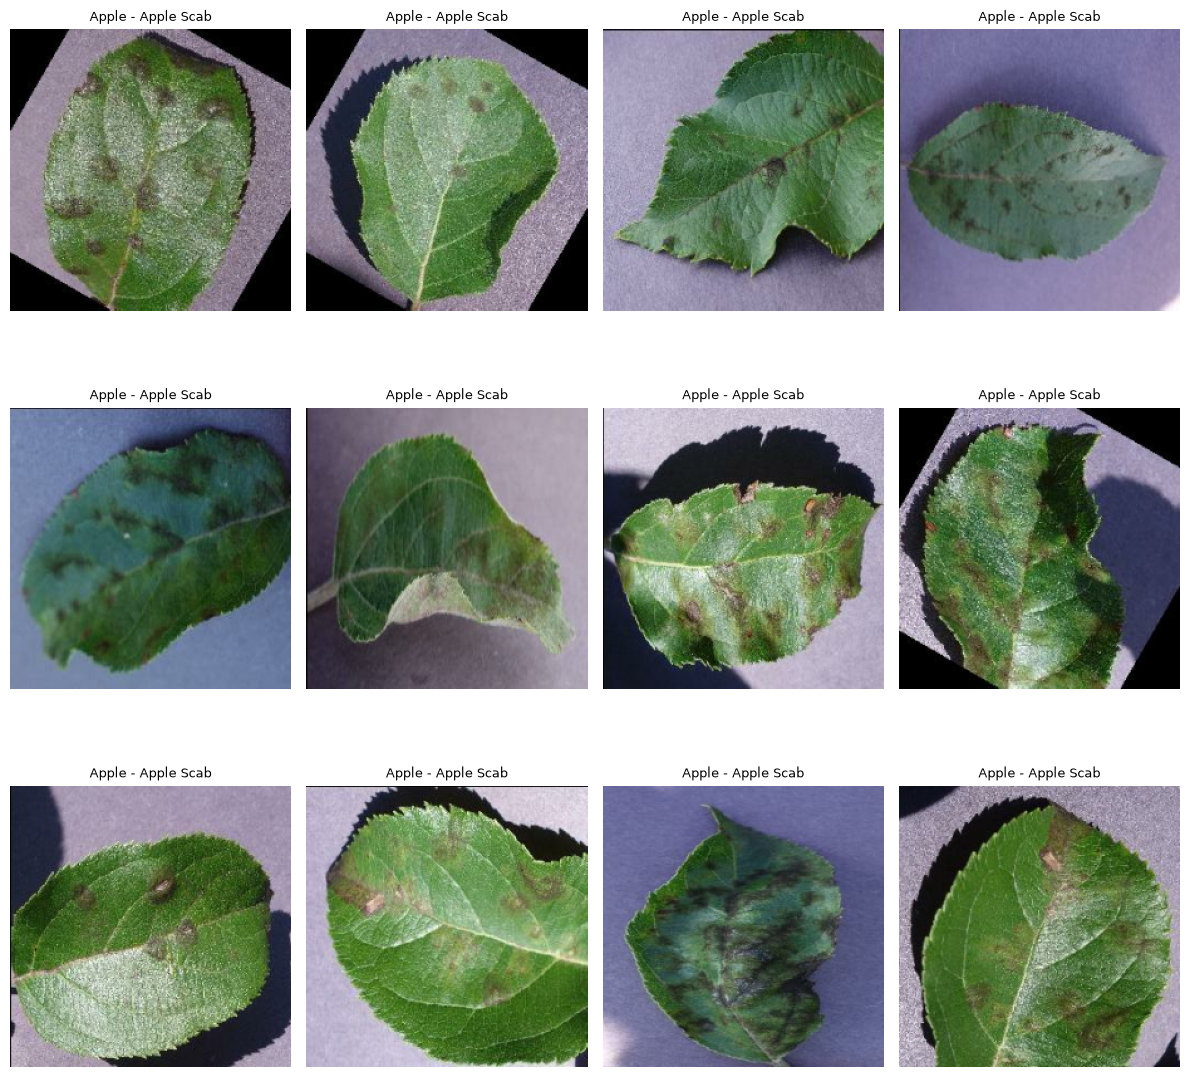

In [12]:
class_names = label_encoder.classes_
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 12))
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        label_index = int(labels[i].numpy())
        plt.title(class_names[label_index], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

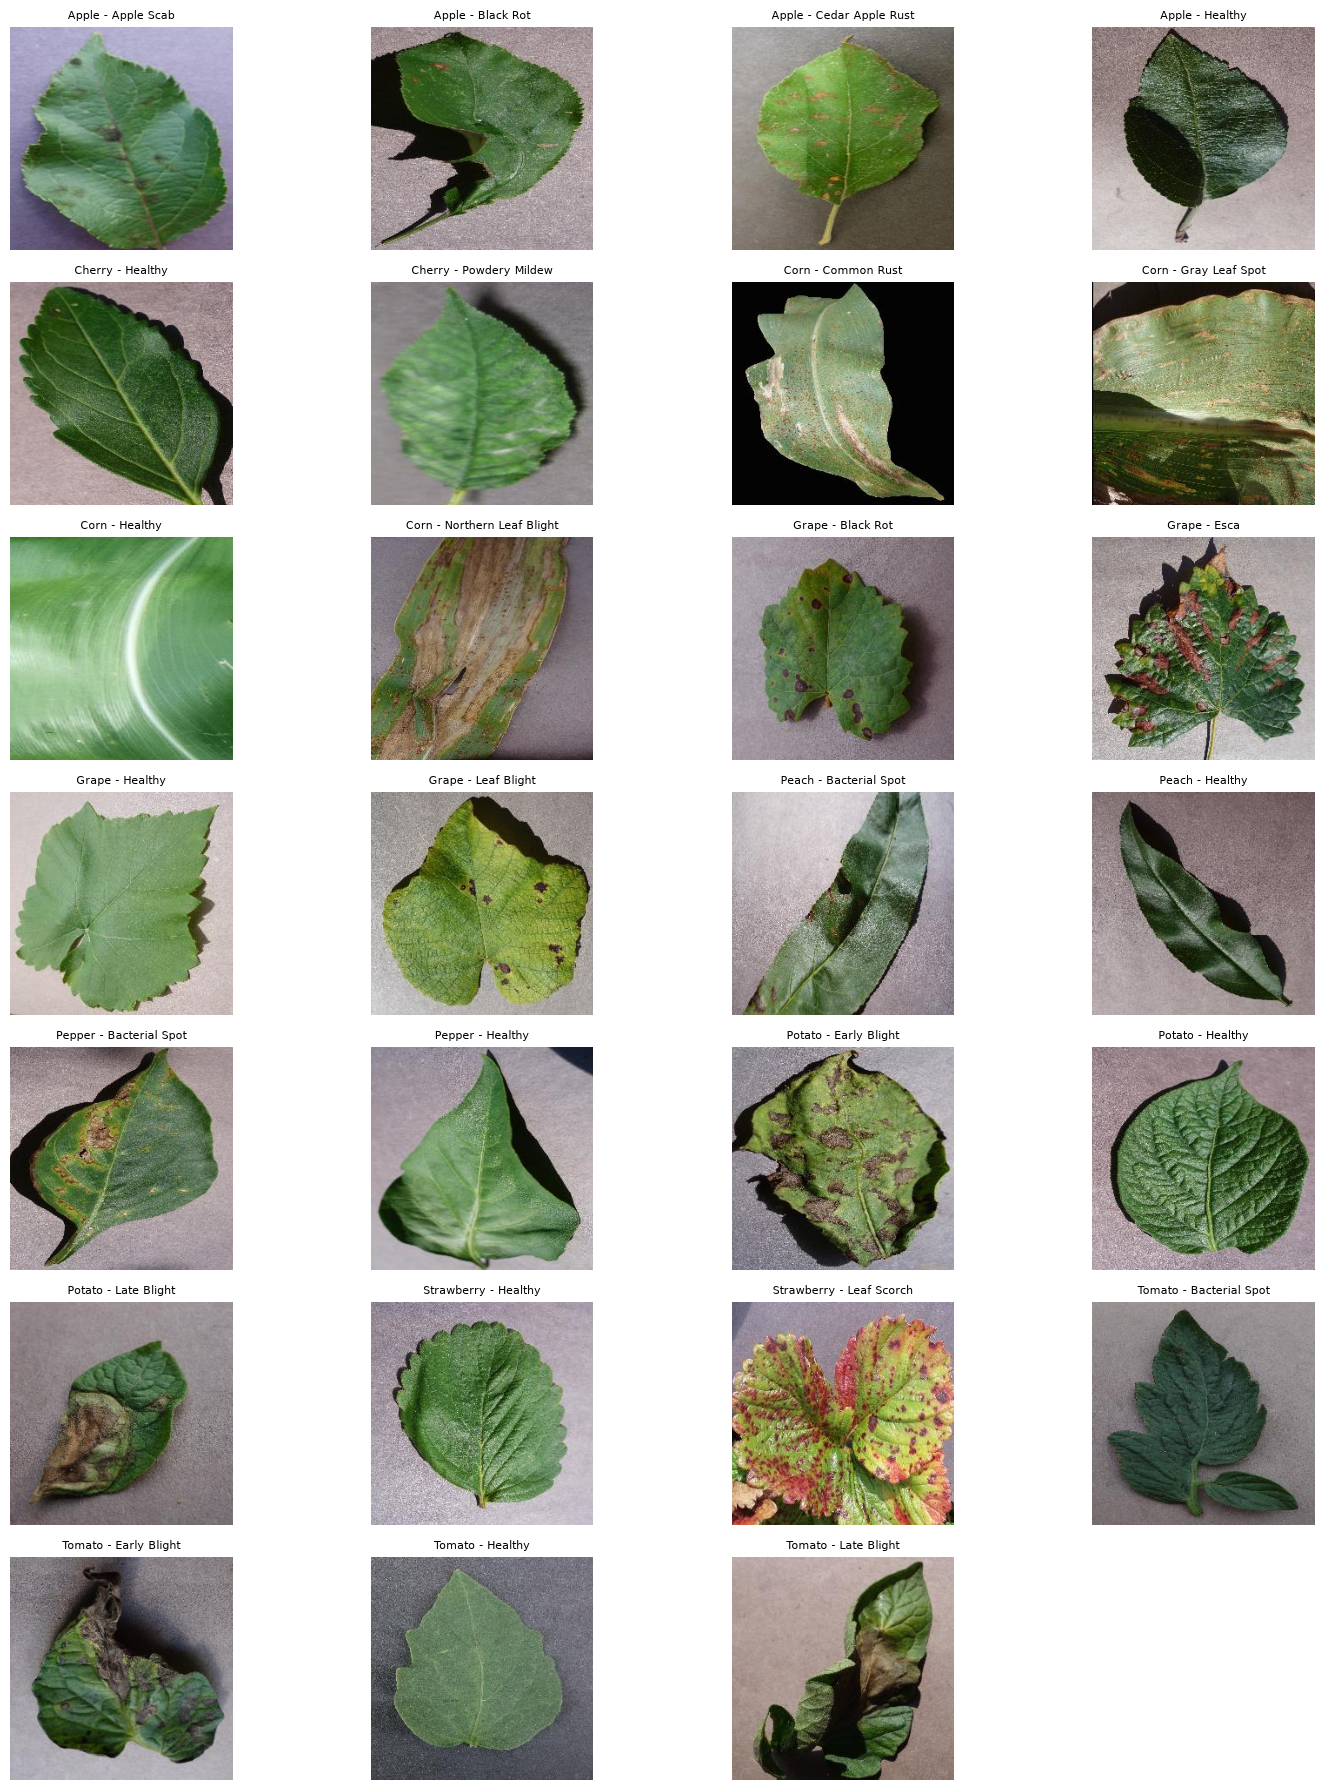

In [13]:
from PIL import Image
class_names = label_encoder.classes_
plt.figure(figsize=(15, 18))
for class_id in range(len(class_names)):
    indices = np.where(np.array(train_labels_encoded) == class_id)[0]
    if len(indices) == 0:
        continue
    image_path = train_paths[indices[0]]
    image = Image.open(image_path).convert("RGB")
    plt.subplot(7, 4, class_id + 1)
    plt.imshow(image)
    plt.title(class_names[class_id], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.10)])
print("Data augmentation created successfully.")

Data augmentation created successfully.


In [15]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet")
base_model.trainable = False
print("MobileNetV2 loaded successfully.")
print("Total layers :", len(base_model.layers))
print("Trainable    :", base_model.trainable)

MobileNetV2 loaded successfully.
Total layers : 154
Trainable    : False


In [16]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# Convert [0, 1] pixels to [-1, 1] for MobileNetV2
x = layers.Rescaling(2.0, offset=-1.0)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │        34,587 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,292,571 (8.75 MB)

 Trainable params: 34,587 (135.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully.")

Model compiled successfully.


In [18]:
checkpoint_path = r"D:\Capstone Project\Farmer---Guide---AI\Model\disease_mobilenetv2_best.keras"
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        mode="max",
        restore_best_weights=True
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )]
print("Callbacks created successfully.")
print("Checkpoint:", checkpoint_path)

Callbacks created successfully.
Checkpoint: D:\Capstone Project\Farmer---Guide---AI\Model\disease_mobilenetv2_best.keras


In [19]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=callbacks)

Epoch 1/10


d:\Capstone Project\Farmer---Guide---AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1539s 977ms/step - accuracy: 0.6038 - loss: 1.7342 - val_accuracy: 0.0485 - val_loss: 5.0615 - learning_rate: 1.0000e-04
Epoch 2/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1410s 899ms/step - accuracy: 0.7666 - loss: 0.9067 - val_accuracy: 0.1175 - val_loss: 3.4245 - learning_rate: 1.0000e-04
Epoch 3/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1460s 934ms/step - accuracy: 0.8471 - loss: 0.5664 - val_accuracy: 0.2363 - val_loss: 2.4676 - learning_rate: 1.0000e-04
Epoch 4/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1471s 937ms/step - accuracy: 0.8842 - loss: 0.4075 - val_accuracy: 0.3596 - val_loss: 1.9895 - learning_rate: 1.0000e-04
Epoch 5/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1459s 929ms/step - accuracy: 0.9069 - loss: 0.3268 - val_accuracy: 0.4758 - val_loss: 1.5676 - learning_rate: 1.0000e-04
Epoch 6/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1481s 942ms/step - accuracy: 0.9193 - loss: 0.2720 - val_accuracy: 0.5358 - val_loss: 1.3850 - learning_rate: 1.0000e-04
Epoch 7/10
1562/1562 ━━━━━━━━━━━━

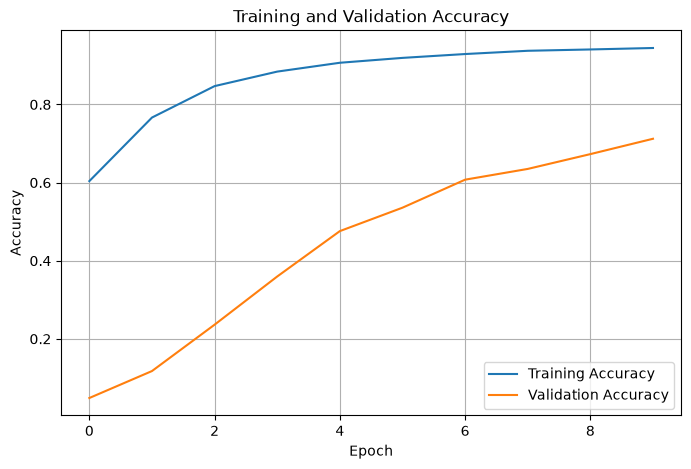

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

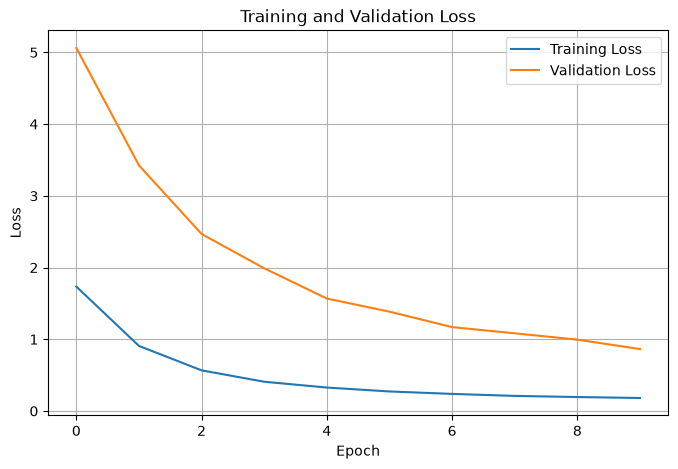

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"]) * 100
best_train_accuracy = history.history["accuracy"][best_epoch - 1] * 100

print("=" * 50)
print("BEST EPOCH :", best_epoch)
print("BEST TRAINING ACCURACY :", best_train_accuracy)
print("BEST VALIDATION ACCURACY :", best_val_accuracy)
print("=" * 50)

BEST EPOCH : 10
BEST TRAINING ACCURACY : 94.46622729301453
BEST VALIDATION ACCURACY : 71.22619152069092


In [23]:
val_loss, val_accuracy = model.evaluate(valid_ds)

print("=" * 50)
print("Validation Loss :", val_loss)
print("Validation Accuracy :", val_accuracy * 100)
print("=" * 50)

391/391 ━━━━━━━━━━━━━━━━━━━━ 225s 576ms/step - accuracy: 0.7123 - loss: 0.8632
Validation Loss : 0.8631689548492432
Validation Accuracy : 71.22619152069092


In [24]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

Classification Report:

                             precision    recall  f1-score   support

         Apple - Apple Scab     1.0000    0.2619    0.4151       504
          Apple - Black Rot     1.0000    0.3823    0.5531       497
   Apple - Cedar Apple Rust     0.9568    0.6045    0.7409       440
            Apple - Healthy     0.9719    0.6195    0.7567       502
           Cherry - Healthy     0.9884    0.7456    0.8500       456
    Cherry - Powdery Mildew     1.0000    0.5929    0.7444       420
         Corn - Common Rust     0.9955    0.9266    0.9598       477
      Corn - Gray Leaf Spot     1.0000    0.4561    0.6265       410
             Corn - Healthy     0.9957    0.9957    0.9957       465
Corn - Northern Leaf Blight     0.6710    0.9832    0.7976       477
          Grape - Black Rot     1.0000    0.7733    0.8722       472
               Grape - Esca     0.8757    0.9833    0.9264       480
            Grape - Healthy     0.9881    0.7825    0.8734       423
        G

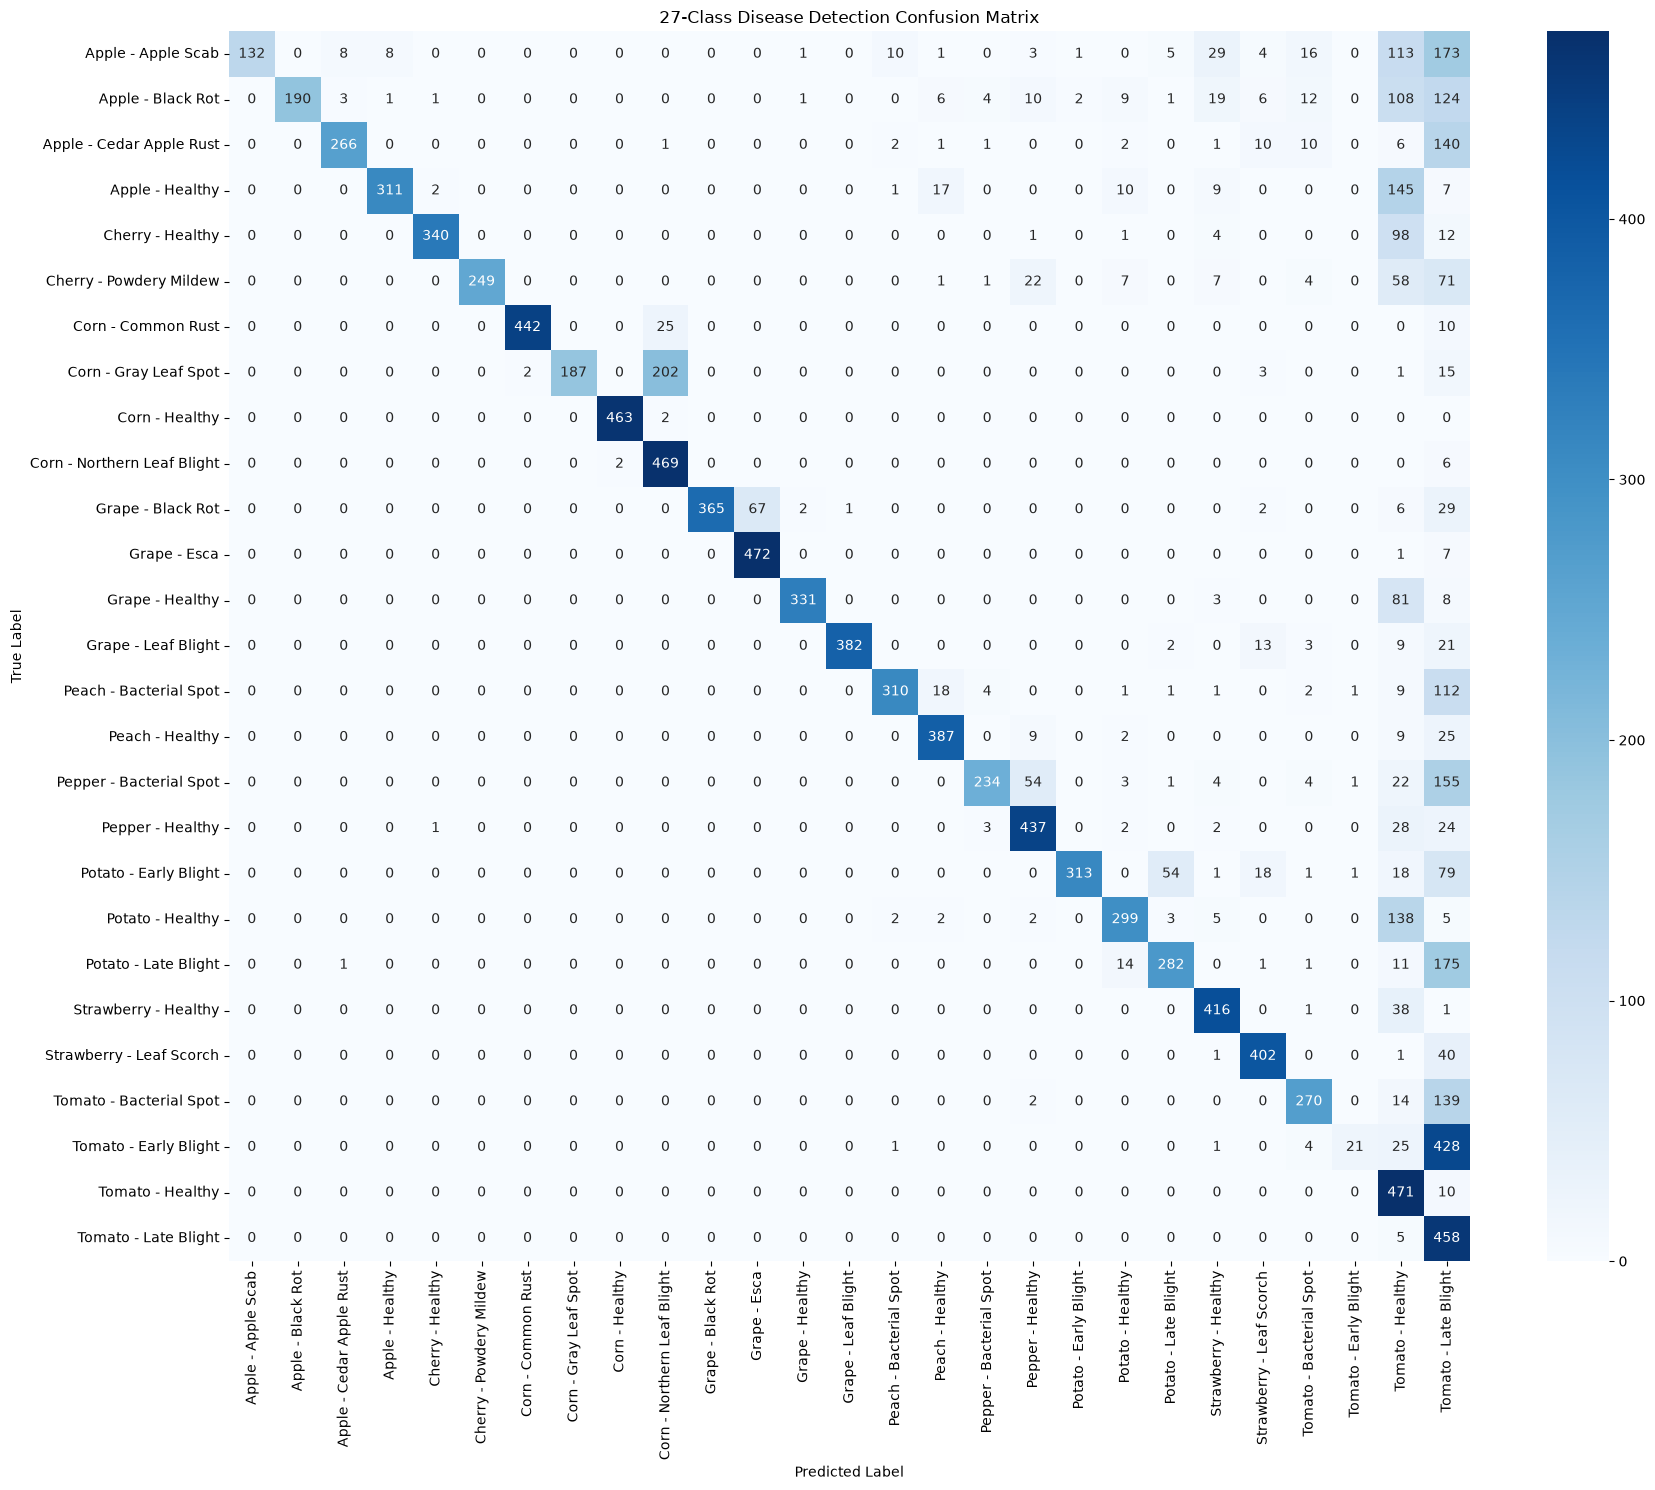

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("27-Class Disease Detection Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
# Copy confusion matrix
cm_no_diag = cm.copy()

# Correct predictions ko remove karo
np.fill_diagonal(cm_no_diag, 0)

# Highest confusion pairs
confusion_pairs = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm_no_diag[i, j] > 0:
            confusion_pairs.append(
                (cm_no_diag[i, j], class_names[i], class_names[j])
            )

# Highest se lowest sort
confusion_pairs = sorted(
    confusion_pairs,
    key=lambda x: x[0],
    reverse=True
)

print("Top 20 Confusion Pairs:\n")

for count, actual, predicted in confusion_pairs[:20]:
    print(f"{actual}  -->  {predicted} : {count}")

Top 20 Confusion Pairs:

Tomato - Early Blight  -->  Tomato - Late Blight : 428
Corn - Gray Leaf Spot  -->  Corn - Northern Leaf Blight : 202
Potato - Late Blight  -->  Tomato - Late Blight : 175
Apple - Apple Scab  -->  Tomato - Late Blight : 173
Pepper - Bacterial Spot  -->  Tomato - Late Blight : 155
Apple - Healthy  -->  Tomato - Healthy : 145
Apple - Cedar Apple Rust  -->  Tomato - Late Blight : 140
Tomato - Bacterial Spot  -->  Tomato - Late Blight : 139
Potato - Healthy  -->  Tomato - Healthy : 138
Apple - Black Rot  -->  Tomato - Late Blight : 124
Apple - Apple Scab  -->  Tomato - Healthy : 113
Peach - Bacterial Spot  -->  Tomato - Late Blight : 112
Apple - Black Rot  -->  Tomato - Healthy : 108
Cherry - Healthy  -->  Tomato - Healthy : 98
Grape - Healthy  -->  Tomato - Healthy : 81
Potato - Early Blight  -->  Tomato - Late Blight : 79
Cherry - Powdery Mildew  -->  Tomato - Late Blight : 71
Grape - Black Rot  -->  Grape - Esca : 67
Cherry - Powdery Mildew  -->  Tomato - Healthy

In [27]:
from tensorflow.keras.utils import load_img, img_to_array

test_dir = r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantDiseaseV2\test"

image_files = [
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total test images:", len(image_files))
print("\nPredictions:\n")

for filename in image_files:

    image_path = os.path.join(test_dir, filename)

    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(
        img_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    predicted_class = class_names[predicted_index]

    print(
        f"{filename:35} -> "
        f"{predicted_class:35} "
        f"Confidence: {confidence:.2f}%"
    )

Total test images: 39

Predictions:

AppleCedarRust1.JPG                 -> Tomato - Late Blight                Confidence: 39.48%
AppleCedarRust2.JPG                 -> Apple - Cedar Apple Rust            Confidence: 30.15%
AppleCedarRust3.JPG                 -> Tomato - Late Blight                Confidence: 94.88%
AppleCedarRust4.JPG                 -> Apple - Cedar Apple Rust            Confidence: 70.47%
AppleScab1.JPG                      -> Tomato - Late Blight                Confidence: 31.68%
AppleScab2.JPG                      -> Tomato - Bacterial Spot             Confidence: 51.12%
AppleScab3.JPG                      -> Tomato - Healthy                    Confidence: 64.70%
CherryHealthy.JPG                   -> Tomato - Late Blight                Confidence: 65.13%
CherryPowderyMildew.JPG             -> Tomato - Late Blight                Confidence: 69.33%
CornCommonRust1.JPG                 -> Corn - Common Rust                  Confidence: 96.81%
CornCommonRust2.JPG    

In [28]:
print("Class-wise Validation Accuracy:\n")

for i, class_name in enumerate(class_names):

    total = np.sum(y_true == i)
    correct = np.sum((y_true == i) & (y_pred == i))

    accuracy = correct / total if total > 0 else 0

    print(
        f"{class_name:35} "
        f"{correct:4}/{total:<4} "
        f"Accuracy: {accuracy*100:6.2f}%"
    )

Class-wise Validation Accuracy:

Apple - Apple Scab                   132/504  Accuracy:  26.19%
Apple - Black Rot                    190/497  Accuracy:  38.23%
Apple - Cedar Apple Rust             266/440  Accuracy:  60.45%
Apple - Healthy                      311/502  Accuracy:  61.95%
Cherry - Healthy                     340/456  Accuracy:  74.56%
Cherry - Powdery Mildew              249/420  Accuracy:  59.29%
Corn - Common Rust                   442/477  Accuracy:  92.66%
Corn - Gray Leaf Spot                187/410  Accuracy:  45.61%
Corn - Healthy                       463/465  Accuracy:  99.57%
Corn - Northern Leaf Blight          469/477  Accuracy:  98.32%
Grape - Black Rot                    365/472  Accuracy:  77.33%
Grape - Esca                         472/480  Accuracy:  98.33%
Grape - Healthy                      331/423  Accuracy:  78.25%
Grape - Leaf Blight                  382/430  Accuracy:  88.84%
Peach - Bacterial Spot               310/459  Accuracy:  67.54%
Peach -

In [29]:
print("Training Class Counts:\n")

# Unique labels and their counts
unique_labels, label_counts = np.unique(
    train_labels,
    return_counts=True
)

for label, count in zip(unique_labels, label_counts):
    print(f"{label} : {count}")

print("\n--- Tomato Blight Counts ---")

# Check whether labels are numeric or text
print("train_labels dtype:", np.array(train_labels).dtype)

# Tomato class names
early_name = "Tomato - Early Blight"
late_name = "Tomato - Late Blight"

# Find their positions in class_names
early_idx = np.where(
    np.array(class_names) == early_name
)[0][0]

late_idx = np.where(
    np.array(class_names) == late_name
)[0][0]

print("Tomato Early Blight class index:", early_idx)
print("Tomato Late Blight class index:", late_idx)

# Counts
early_count = np.sum(np.array(train_labels) == early_idx)
late_count = np.sum(np.array(train_labels) == late_idx)

print("Tomato Early Blight:", early_count)
print("Tomato Late Blight:", late_count)

Training Class Counts:

Apple - Apple Scab : 2016
Apple - Black Rot : 1987
Apple - Cedar Apple Rust : 1760
Apple - Healthy : 2008
Cherry - Healthy : 1826
Cherry - Powdery Mildew : 1683
Corn - Common Rust : 1907
Corn - Gray Leaf Spot : 1642
Corn - Healthy : 1859
Corn - Northern Leaf Blight : 1908
Grape - Black Rot : 1888
Grape - Esca : 1920
Grape - Healthy : 1692
Grape - Leaf Blight : 1722
Peach - Bacterial Spot : 1838
Peach - Healthy : 1728
Pepper - Bacterial Spot : 1913
Pepper - Healthy : 1988
Potato - Early Blight : 1939
Potato - Healthy : 1824
Potato - Late Blight : 1939
Strawberry - Healthy : 1824
Strawberry - Leaf Scorch : 1774
Tomato - Bacterial Spot : 1702
Tomato - Early Blight : 1920
Tomato - Healthy : 1926
Tomato - Late Blight : 1851

--- Tomato Blight Counts ---
train_labels dtype: <U27
Tomato Early Blight class index: 24
Tomato Late Blight class index: 26
Tomato Early Blight: 0
Tomato Late Blight: 0


In [30]:
train_labels_array = np.array(train_labels)

early_name = "Tomato - Early Blight"
late_name = "Tomato - Late Blight"

early_count = np.sum(train_labels_array == early_name)
late_count = np.sum(train_labels_array == late_name)

print("Tomato Early Blight:", early_count)
print("Tomato Late Blight:", late_count)

print("\nTomato class distribution:")
print(
    "Early Blight :",
    early_count
)

print(
    "Late Blight  :",
    late_count
)

Tomato Early Blight: 1920
Tomato Late Blight: 1851

Tomato class distribution:
Early Blight : 1920
Late Blight  : 1851


Early Blight images: 1920
Late Blight images : 1851


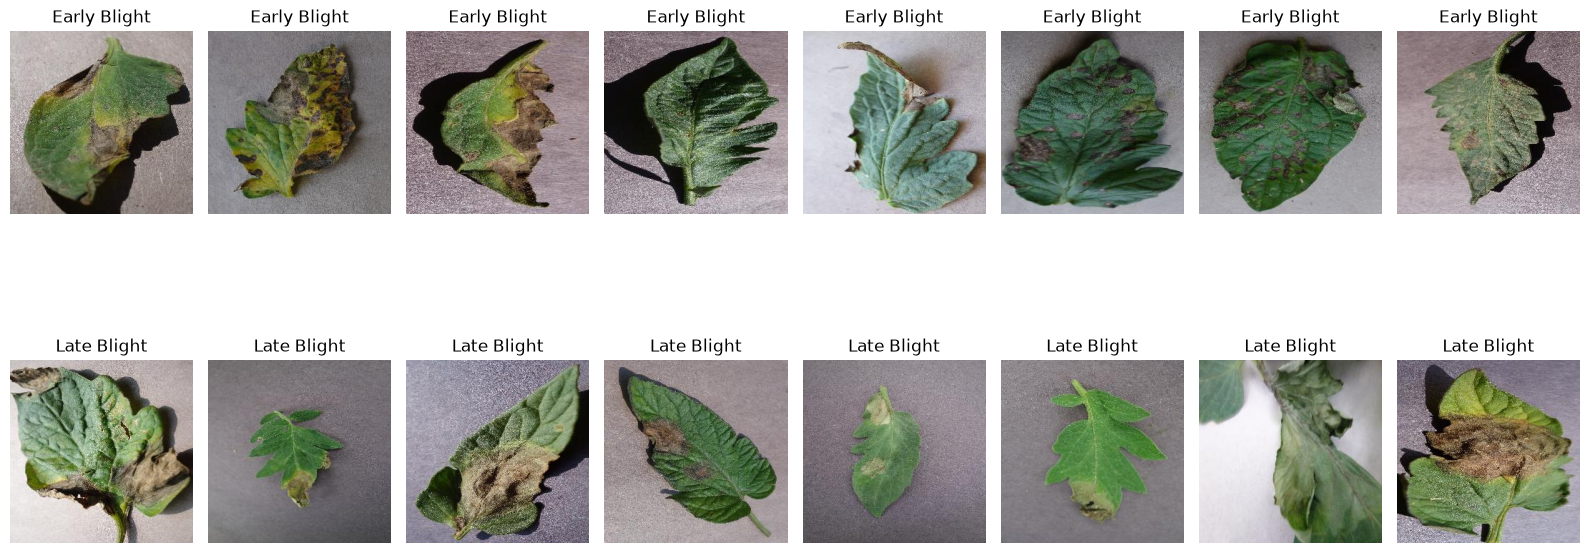

In [31]:
import random

train_labels_array = np.array(train_labels)

early_indices = np.where(
    train_labels_array == "Tomato - Early Blight"
)[0]

late_indices = np.where(
    train_labels_array == "Tomato - Late Blight"
)[0]

print("Early Blight images:", len(early_indices))
print("Late Blight images :", len(late_indices))

early_samples = random.sample(
    list(early_indices),
    min(8, len(early_indices))
)

late_samples = random.sample(
    list(late_indices),
    min(8, len(late_indices))
)

plt.figure(figsize=(16, 8))

for i, idx in enumerate(early_samples):
    img = plt.imread(train_paths[idx])

    plt.subplot(2, 8, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Early Blight")

for i, idx in enumerate(late_samples):
    img = plt.imread(train_paths[idx])

    plt.subplot(2, 8, i + 9)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Late Blight")

plt.tight_layout()
plt.show()

In [32]:
early_idx = np.where(
    np.array(class_names) == "Tomato - Early Blight"
)[0][0]

late_idx = np.where(
    np.array(class_names) == "Tomato - Late Blight"
)[0][0]

print("Tomato Early Blight index:", early_idx)
print("Tomato Late Blight index :", late_idx)

print("\nEarly Blight Validation Predictions:\n")

count = 0

for images, labels in valid_ds:

    predictions = model.predict(images, verbose=0)

    labels_np = labels.numpy()

    # Only actual Early Blight images
    for i in range(len(labels_np)):

        if labels_np[i] == early_idx:

            probs = predictions[i]

            top_indices = np.argsort(probs)[::-1][:5]

            print(f"\nImage {count + 1}")

            for idx in top_indices:
                print(
                    f"{class_names[idx]:35} "
                    f"{probs[idx] * 100:.2f}%"
                )

            count += 1

            # First 10 samples only
            if count >= 10:
                break

    if count >= 10:
        break

Tomato Early Blight index: 24
Tomato Late Blight index : 26

Early Blight Validation Predictions:


Image 1
Tomato - Bacterial Spot             34.53%
Tomato - Early Blight               18.74%
Apple - Apple Scab                  13.22%
Tomato - Late Blight                11.44%
Tomato - Healthy                    4.00%

Image 2
Tomato - Late Blight                79.32%
Tomato - Early Blight               14.13%
Tomato - Healthy                    2.13%
Tomato - Bacterial Spot             1.65%
Strawberry - Leaf Scorch            1.63%

Image 3
Tomato - Late Blight                78.22%
Tomato - Bacterial Spot             14.86%
Tomato - Early Blight               5.31%
Tomato - Healthy                    1.03%
Strawberry - Leaf Scorch            0.16%

Image 4
Tomato - Healthy                    37.48%
Tomato - Late Blight                37.46%
Tomato - Early Blight               15.42%
Tomato - Bacterial Spot             6.21%
Grape - Esca                        0.86%

Image 5
Tomat

In [33]:
print("Starting targeted fine-tuning...")

# --------------------------------------------------
# 1. Save the current trained model safely
# --------------------------------------------------

current_model_path = "Model/disease_model_before_finetuning.keras"

model.save(current_model_path)

print("Current model saved at:")
print(current_model_path)


# --------------------------------------------------
# 2. Unfreeze MobileNetV2 backbone
# --------------------------------------------------

base_model.trainable = True


# --------------------------------------------------
# 3. Freeze lower layers
#    Only upper 30 layers will be fine-tuned
# --------------------------------------------------

fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


# Keep BatchNormalization layers frozen
# because the dataset is already large and CPU training
# should remain stable.

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


print("\nMobileNetV2 layer status:")
print("Total layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)

trainable_count = sum(
    1 for layer in base_model.layers
    if layer.trainable
)

print("Trainable MobileNetV2 layers:", trainable_count)


# --------------------------------------------------
# 4. Recompile with very small learning rate
# --------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# --------------------------------------------------
# 5. Fine-tuning callbacks
# --------------------------------------------------

fine_tune_checkpoint = "Model/disease_model_finetuned_best.keras"

fine_tune_callbacks = [

    ModelCheckpoint(
        fine_tune_checkpoint,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]


# --------------------------------------------------
# 6. Fine-tune for only 5 epochs
# --------------------------------------------------

fine_tune_history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=fine_tune_callbacks
)

print("\nFine-tuning completed.")

Starting targeted fine-tuning...
Current model saved at:
Model/disease_model_before_finetuning.keras

MobileNetV2 layer status:
Total layers: 154
Fine-tuning from layer: 124
Trainable MobileNetV2 layers: 19
Epoch 1/5


d:\Capstone Project\Farmer---Guide---AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.9679 - loss: 0.1017
Epoch 1: val_accuracy improved from None to 0.64695, saving model to Model/disease_model_finetuned_best.keras

Epoch 1: finished saving model to Model/disease_model_finetuned_best.keras
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1512s 960ms/step - accuracy: 0.9679 - loss: 0.1017 - val_accuracy: 0.6470 - val_loss: 1.1437 - learning_rate: 1.0000e-05
Epoch 2/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.9746 - loss: 0.0824
Epoch 2: val_accuracy improved from 0.64695 to 0.68649, saving model to Model/disease_model_finetuned_best.keras

Epoch 2: finished saving model to Model/disease_model_finetuned_best.keras
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1867s 1s/step - accuracy: 0.9746 - loss: 0.0824 - val_accuracy: 0.6865 - val_loss: 0.9902 - learning_rate: 1.0000e-05
Epoch 3/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.9793 - loss: 0.0663
Epoch 3: val_accuracy improved from 0.68649 to 0.69601, saving mode

In [35]:
# ==========================================
# CELL 33 - FINAL FINE-TUNED MODEL EVALUATION
# ==========================================

import numpy as np
from sklearn.metrics import classification_report

print("==========================================")
print("FINAL FINE-TUNED MODEL EVALUATION")
print("==========================================")

# ------------------------------------------
# 1. Validation Accuracy
# ------------------------------------------

val_loss, val_accuracy = model.evaluate(
    valid_ds,
    verbose=1
)

print("\nFinal Validation Results")
print("------------------------")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy * 100:.2f}%")

# ------------------------------------------
# 2. Generate Predictions
# ------------------------------------------

print("\nGenerating validation predictions...")

y_true = []
y_pred = []

for images, labels in valid_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")

# ------------------------------------------
# 3. Make sure class_names is a normal list
# ------------------------------------------

class_names_list = list(class_names)

print("\nNumber of Classes :", len(class_names_list))

# ------------------------------------------
# 4. Classification Report
# ------------------------------------------

print("\n==========================================")
print("CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(class_names_list)),
        target_names=class_names_list,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------
# 5. Find Tomato Early Blight
# ------------------------------------------

early_matches = [
    i for i, name in enumerate(class_names_list)
    if "Tomato" in name and "Early Blight" in name
]

late_matches = [
    i for i, name in enumerate(class_names_list)
    if "Tomato" in name and "Late Blight" in name
]

print("\n==========================================")
print("TOMATO BLIGHT ANALYSIS")
print("==========================================")

print("Early Blight match :", early_matches)
print("Late Blight match  :", late_matches)

# ------------------------------------------
# 6. Early Blight Performance
# ------------------------------------------

if early_matches and late_matches:

    early_blight_index = early_matches[0]
    late_blight_index = late_matches[0]

    early_total = np.sum(
        y_true == early_blight_index
    )

    early_correct = np.sum(
        (y_true == early_blight_index) &
        (y_pred == early_blight_index)
    )

    early_to_late = np.sum(
        (y_true == early_blight_index) &
        (y_pred == late_blight_index)
    )

    print("\nTomato Early Blight")
    print("-------------------")
    print("Correct Predictions :", early_correct)
    print("Total Images        :", early_total)

    if early_total > 0:

        early_recall = (
            early_correct / early_total
        ) * 100

        print(
            f"Recall              : {early_recall:.2f}%"
        )

    print("\nTomato Early Blight -> Tomato Late Blight")
    print("-----------------------------------------")
    print(
        "Misclassified Images :",
        early_to_late
    )

else:

    print("\nWARNING:")
    print("Tomato Early Blight / Late Blight")
    print("class name could not be found.")

# ------------------------------------------
# 7. Final Decision Summary
# ------------------------------------------

print("\n==========================================")
print("FINAL MODEL SUMMARY")
print("==========================================")

print(
    f"Validation Accuracy : {val_accuracy * 100:.2f}%"
)

print(
    f"Validation Loss     : {val_loss:.4f}"
)

print("\nFine-tuned model evaluation completed.")

FINAL FINE-TUNED MODEL EVALUATION
391/391 ━━━━━━━━━━━━━━━━━━━━ 227s 581ms/step - accuracy: 0.7015 - loss: 0.9234

Final Validation Results
------------------------
Validation Loss     : 0.9234
Validation Accuracy : 70.15%

Generating validation predictions...
Predictions generated successfully.

Number of Classes : 27

CLASSIFICATION REPORT
                             precision    recall  f1-score   support

         Apple - Apple Scab     1.0000    0.4425    0.6135       504
          Apple - Black Rot     0.9892    0.7344    0.8430       497
   Apple - Cedar Apple Rust     0.9812    0.3568    0.5233       440
            Apple - Healthy     0.9754    0.7112    0.8226       502
           Cherry - Healthy     0.9878    0.7105    0.8265       456
    Cherry - Powdery Mildew     0.9960    0.5905    0.7414       420
         Corn - Common Rust     0.9976    0.8826    0.9366       477
      Corn - Gray Leaf Spot     1.0000    0.3854    0.5563       410
             Corn - Healthy     1.0

FINAL CONFUSION MATRIX ANALYSIS
Predictions generated successfully.
Total validation images : 12494
Total classes           : 27


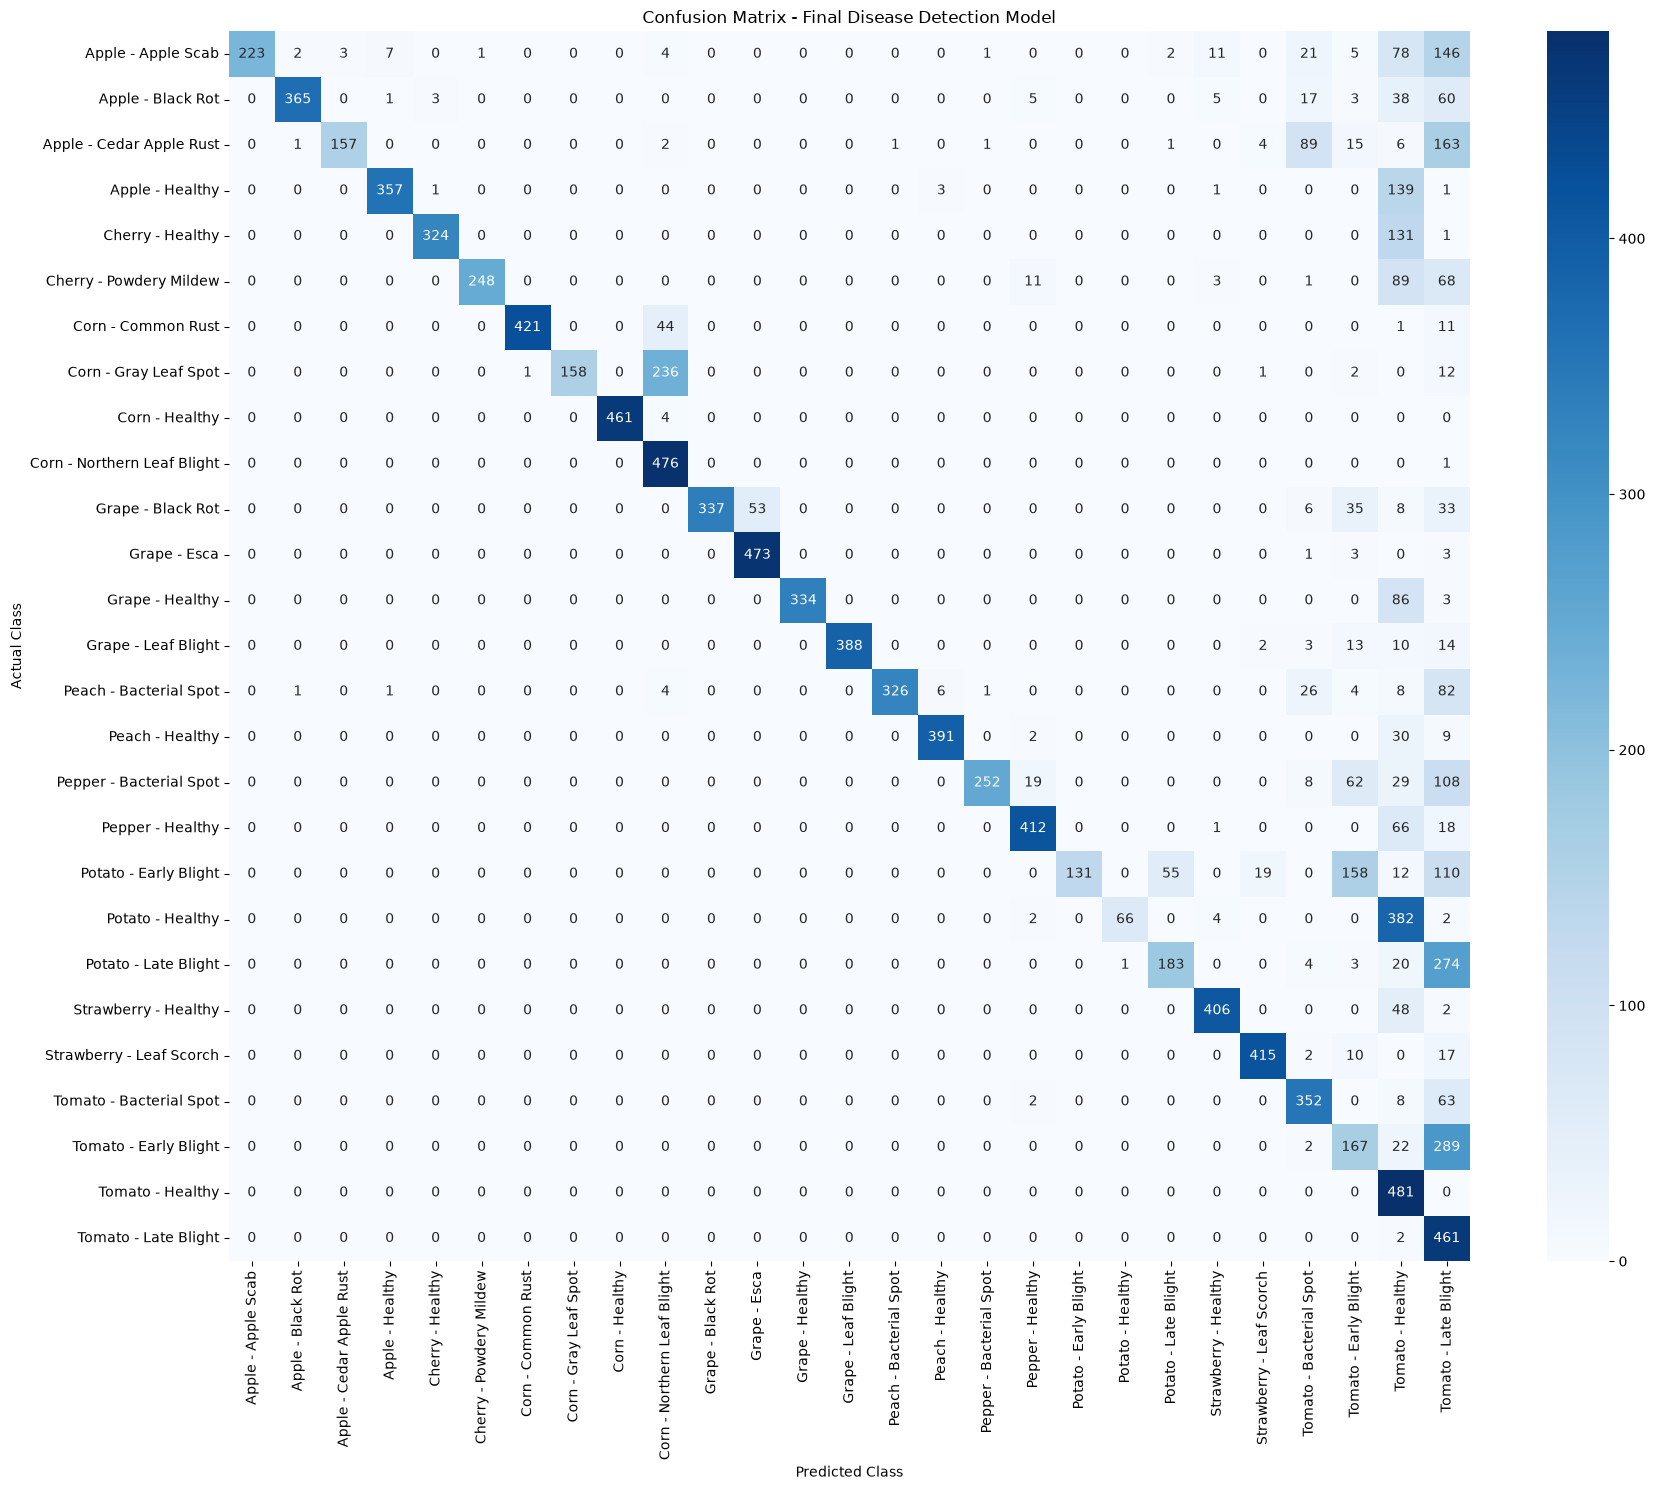


TOMATO EARLY / LATE BLIGHT ANALYSIS

Tomato Early Blight
-------------------
Total images        : 480
Correct predictions : 167
Predicted as Late   : 289
Recall              : 34.79%

Tomato Late Blight
------------------
Total images        : 463
Correct predictions : 461
Recall              : 99.57%

Early Blight -> Late Blight
---------------------------
Misclassified images : 289

FINAL MODEL DECISION

Fine-tuning result:
Original best validation accuracy : ~71.00%
Fine-tuned validation accuracy    : 70.15%

Decision:
The original best model should be retained
as the final disease detection model.

No further training is required at this stage.

CONFUSION MATRIX ANALYSIS COMPLETED


In [36]:
# ==========================================
# CELL 34 - FINAL CONFUSION MATRIX ANALYSIS
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("==========================================")
print("FINAL CONFUSION MATRIX ANALYSIS")
print("==========================================")

# ------------------------------------------
# 1. Generate predictions
# ------------------------------------------

y_true = []
y_pred = []

for images, labels in valid_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names_list = list(class_names)

print("Predictions generated successfully.")
print("Total validation images :", len(y_true))
print("Total classes           :", len(class_names_list))

# ------------------------------------------
# 2. Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names_list))
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_list,
    yticklabels=class_names_list
)

plt.title("Confusion Matrix - Final Disease Detection Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

# ------------------------------------------
# 3. Tomato Early / Late Blight Analysis
# ------------------------------------------

early_matches = [
    i for i, name in enumerate(class_names_list)
    if "Tomato" in name and "Early Blight" in name
]

late_matches = [
    i for i, name in enumerate(class_names_list)
    if "Tomato" in name and "Late Blight" in name
]

print("\n==========================================")
print("TOMATO EARLY / LATE BLIGHT ANALYSIS")
print("==========================================")

if early_matches and late_matches:

    early_index = early_matches[0]
    late_index = late_matches[0]

    early_total = np.sum(
        y_true == early_index
    )

    early_correct = np.sum(
        (y_true == early_index) &
        (y_pred == early_index)
    )

    early_to_late = np.sum(
        (y_true == early_index) &
        (y_pred == late_index)
    )

    late_total = np.sum(
        y_true == late_index
    )

    late_correct = np.sum(
        (y_true == late_index) &
        (y_pred == late_index)
    )

    print("\nTomato Early Blight")
    print("-------------------")
    print("Total images        :", early_total)
    print("Correct predictions :", early_correct)
    print("Predicted as Late   :", early_to_late)

    if early_total > 0:
        early_recall = (
            early_correct / early_total
        ) * 100

        print(
            f"Recall              : {early_recall:.2f}%"
        )

    print("\nTomato Late Blight")
    print("------------------")
    print("Total images        :", late_total)
    print("Correct predictions :", late_correct)

    if late_total > 0:
        late_recall = (
            late_correct / late_total
        ) * 100

        print(
            f"Recall              : {late_recall:.2f}%"
        )

    print("\nEarly Blight -> Late Blight")
    print("---------------------------")
    print(
        "Misclassified images :",
        early_to_late
    )

else:

    print("Tomato Early/Late Blight class not found.")

# ------------------------------------------
# 4. Final Decision
# ------------------------------------------

print("\n==========================================")
print("FINAL MODEL DECISION")
print("==========================================")

print("""
Fine-tuning result:
Original best validation accuracy : ~71.00%
Fine-tuned validation accuracy    : 70.15%

Decision:
The original best model should be retained
as the final disease detection model.

No further training is required at this stage.
""")

print("==========================================")
print("CONFUSION MATRIX ANALYSIS COMPLETED")
print("==========================================")